# **Lab 02 - Introduction to Q-learning**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Implementing Q-learning with the FrozenLake-v1 environment

In [91]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random
import numpy as np
import matplotlib.pyplot as plt

1. ĐANG HUẤN LUYỆN (TRAINING) AGENT...
Huấn luyện xong! Bắt đầu đánh giá...


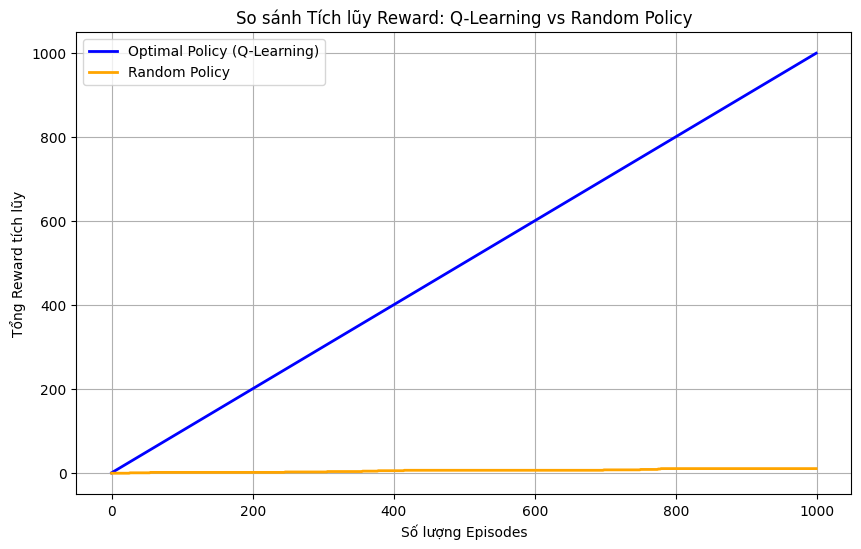

Training completed. Q-table:
State: 0, Action: 0, Q-value: 0.50
State: 0, Action: 1, Q-value: 0.59
State: 0, Action: 2, Q-value: 0.31
State: 0, Action: 3, Q-value: 0.46
State: 1, Action: 0, Q-value: 0.47
State: 1, Action: 1, Q-value: 0.00
State: 1, Action: 2, Q-value: 0.00
State: 1, Action: 3, Q-value: 0.00
State: 2, Action: 0, Q-value: 0.00
State: 2, Action: 1, Q-value: 0.03
State: 2, Action: 2, Q-value: 0.00
State: 2, Action: 3, Q-value: 0.00
State: 3, Action: 0, Q-value: 0.00
State: 3, Action: 1, Q-value: 0.00
State: 3, Action: 2, Q-value: 0.00
State: 3, Action: 3, Q-value: 0.00
State: 4, Action: 0, Q-value: 0.54
State: 4, Action: 1, Q-value: 0.66
State: 4, Action: 2, Q-value: 0.00
State: 4, Action: 3, Q-value: 0.49
State: 6, Action: 0, Q-value: 0.00
State: 6, Action: 1, Q-value: 0.27
State: 6, Action: 2, Q-value: 0.00
State: 6, Action: 3, Q-value: 0.00
State: 8, Action: 0, Q-value: 0.57
State: 8, Action: 1, Q-value: 0.00
State: 8, Action: 2, Q-value: 0.73
State: 8, Action: 3, Q-val

In [92]:
# ============================================================
# Q-learning agent for Gymnasium FrozenLake-v1
# ------------------------------------------------------------
# This script trains an agent to learn a state-action value table
# Q(s, a) using the Q-learning algorithm and an epsilon-greedy policy.
#
# Environment:
# - FrozenLake-v1 (4x4 by default)
# - is_slippery=False -> deterministic movement (easier learning)
#
# High-level flow:
# 1) Create environment and agent
# 2) Train over many episodes
# 3) Print and export learned Q-table
# 4) Demonstrate the learned policy in text mode and pygame mode
# ============================================================


class QLearningAgent:
    # Agent stores Q-values in a dictionary keyed by (state, action).
    # If a (state, action) pair has never been seen, its Q-value is treated as 0.
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha  # Learning rate: how much to update old Q-values
        self.gamma = gamma  # Discount factor: importance of future rewards
        self.q_table = {}   # Sparse Q-table: {(state, action): q_value}

    def get_q_value(self, state, action):
        # Return Q(s, a). If missing, return 0.0 (default for unseen pairs).
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        # Q-learning update rule:
        #   Q(s,a) <- (1 - alpha)*Q(s,a) + alpha*(reward + gamma*max_a' Q(s',a'))
        #
        # 1) Estimate best possible future value at next_state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_next_q = max(
            self.get_q_value(next_state, a) for a in range(self.env.action_space.n)
        )

        # 2) Current estimate for (state, action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        current_q = self.get_q_value(state, action)

        # 3) Temporal-difference target
        # Reward for current step + discounted best future value
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        target_q = reward + self.gamma*best_next_q

        # 4) Blend old estimate with new target
        # New Q-value is a weighted average of old and new information
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        new_q = (1-self.alpha)*current_q + self.alpha*target_q

        # 5) Save updated Q-value
        self.q_table[(state, action)] = new_q

    def choose_action(self, state, epsilon=0.1, option="q_learning"):
        if option == "random":
            return self.env.action_space.sample()
        # Epsilon-greedy action selection:
        # - With probability epsilon: explore (random action)
        # - Otherwise: exploit (choose action with highest Q-value)

        # 1) Exploration: random action with probability epsilon
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if random.random() < epsilon:
            return self.env.action_space.sample()

        # Compute Q-values for all actions in current state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)

        # Tie-breaking: if multiple actions share max Q, choose randomly among them
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_actions = [
            a for a in range(self.env.action_space.n)
            if q_values[a] == max_q
        ]
        return random.choice(best_actions)

    def choose_greedy_action(self, state):
        # Pure greedy policy (epsilon=0):
        # Always choose one of the best actions by Q-value.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)


def export_q_table_to_txt(agent, file_path="q_table_final.txt"):
    """Export all learned Q-values to a CSV-like text file.

    File format:
        State,Action,Q-value
        0,0,0.000000
        ...
    """
    with open(file_path, "w", encoding="utf-8") as f:
        f.write("State,Action,Q-value\n")
        # Sort keys for stable, readable output
        for (state, action) in sorted(agent.q_table.keys()):
            q_val = agent.q_table[(state, action)]
            f.write(f"{state},{action},{q_val:.6f}\n")
    print(f"Q-table exported to: {file_path}")


def show_final_result_text(agent):
    """Run one full evaluation episode in ANSI text mode.

    - Uses a greedy policy (no exploration).
    - Prints board state after each step.
    - Useful for notebook/terminal environments.
    """
    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (TEXT) ===")
    print(demo_env.render())

    done = False
    step = 0
    reward = 0

    while not done:
        # Pick best action according to learned Q-table
        action = agent.choose_greedy_action(state)

        # Interact with environment
        next_state, reward, terminated, truncated, _ = demo_env.step(action)

        # Episode stops if goal/hole reached (terminated) or cutoff (truncated)
        done = terminated or truncated
        step += 1

        # Log progress and render current map
        print(f"Step {step} - Action: {action}, Reward: {reward}")
        print(demo_env.render())

        # Move to next state
        state = next_state

    # Final status
    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")
    demo_env.close()


def show_final_result_pygame(agent, delay_seconds=0.5):
    """
    Run one full evaluation episode with GUI rendering ("human" mode).

    Note:
    - Requires a local environment that supports opening windows.
    - In remote/notebook servers without display, this may not work.
    """
    import time

    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (PYGAME/HUMAN) ===")
    done = False
    step = 0
    reward = 0

    while not done:
        action = agent.choose_greedy_action(state)
        next_state, reward, terminated, truncated, _ = demo_env.step(action)
        done = terminated or truncated
        step += 1

        print(f"Step {step} - Action: {action}, Reward: {reward}")
        state = next_state

        # Slow down transitions so movement can be observed clearly
        time.sleep(delay_seconds)

    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")

    # Keep final frame visible briefly
    time.sleep(1.0)
    demo_env.close()


# ============================================================
# Training routine
# ============================================================

if __name__ == "__main__":
    # Create deterministic FrozenLake environment for training
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    env = gym.make("FrozenLake-v1", is_slippery=False)

    # Initialize Q-learning agent with default hyperparameters
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    agent = QLearningAgent(env)

    # Number of independent training episodes
    num_episodes = 1000

    print("1. ĐANG HUẤN LUYỆN (TRAINING) AGENT...")
    # ==========================================
    # PHẦN 1: HUẤN LUYỆN (Bắt buộc phải có)
    # ==========================================
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            # Chọn hành động có exploration (epsilon=0.1)
            action = agent.choose_action(state, epsilon=0.1)
            
            # Thực thi
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Cập nhật bảng Q-Table (Agent HỌC ở bước này)
            agent.update_q_value(state, action, reward, next_state)
            
            state = next_state

    print("Huấn luyện xong! Bắt đầu đánh giá...")

    q_learning_rewards = []
    random_rewards = []

    # Optimal Policy(Q-Learning)
    for _ in range(num_episodes):
        # Reset environment at start of each episode
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            # Dùng hàm choose_greedy_action để chạy tối ưu (không khám phá nữa)
            action = agent.choose_greedy_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
        q_learning_rewards.append(episode_reward)

    # Random Policy
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            # Dùng tuỳ chọn option="random" đã thêm ở trên
            action = agent.choose_action(state, option="random")
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
        random_rewards.append(episode_reward)

    cum_q_rewards = np.cumsum(q_learning_rewards)
    cum_random_rewards = np.cumsum(random_rewards)

    plt.figure(figsize=(10, 6))
    plt.plot(cum_q_rewards, label="Optimal Policy (Q-Learning)", color="blue", linewidth=2)
    plt.plot(cum_random_rewards, label="Random Policy", color="orange", linewidth=2)
    
    plt.title("So sánh Tích lũy Reward: Q-Learning vs Random Policy")
    plt.xlabel("Số lượng Episodes")
    plt.ylabel("Tổng Reward tích lũy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print learned Q-table entries
    print("Training completed. Q-table:")
    for (state, action) in sorted(agent.q_table.keys()):
        q_val = agent.q_table[(state, action)]
        print(f"State: {state}, Action: {action}, Q-value: {q_val:.2f}")

    # Save Q-table to file for later inspection/use
    export_q_table_to_txt(agent, "q_table_final.txt")

    # Show one text-based demonstration run
    show_final_result_text(agent)

    # Show one GUI-based demonstration run
    show_final_result_pygame(agent, delay_seconds=0.4)

    # Release training environment resources
    env.close()

## Part 2: Q-learning with Custom Environment "VacuumCleaner"

In [93]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random

In [94]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)
import gymnasium as gym
import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2), obs_mode="encoded"):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)
        self.obs_mode = obs_mode  # "encoded" hoặc "dict"

        self.action_space = gym.spaces.Discrete(4)

        if obs_mode == "encoded":
            self.observation_space = gym.spaces.Discrete(self.m * self.n * 2)
        
        else:
            self.observation_space = gym.spaces.Dict({
                "position": 
                gym.spaces.Box(
                    low=0, 
                    high=max(self.m, self.n), 
                    shape=(2,), 
                    dtype=np.int32),
                
                "dust": 
                gym.spaces.Box(
                    low=0, 
                    high=1, 
                    shape=(self.m, self.n), 
                    dtype=np.int32)
            })

        self.reset()
        
    def _get_obs(self):
        if self.obs_mode == "encoded":
            return self.encode_state()
        else:
            return {
                "position": self.position.copy(),
                "dust": self.dust_grid.copy()
            }
        
    def encode_state(self):
        pos = self.position[0] * self.n + self.position[1]
        x, y = self.position
        nearby_dust = 0
        
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < self.m and 0 <= ny < self.n:
                if self.dust_grid[nx, ny] == 1:
                    nearby_dust = 1
                    break

        return pos * 2 + nearby_dust

    def reset(self, *, seed=None, options=None):
        self.position = np.array([0,0], dtype=np.int32)
        
        self.dust_grid = np.ones((self.m, self.n))
        
        self.step_count = 0
        self.max_steps = 100

        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False

        
        x, y = self.position
        self.dust_grid[x, y] = 0


        return self._get_obs(), {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.step_count += 1

        if action == 0:   # Up
            candidate = self.position + np.array([-1,0])
        elif action == 1: # Down
            candidate = self.position + np.array([1,0])
        elif action == 2: # Left
            candidate = self.position + np.array([0,-1])
        elif action == 3: # Right
            candidate = self.position + np.array([0,1])
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                self.total_reward += reward

                state = self.encode_state()
                return state, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        x, y = self.position

        if self.dust_grid[x, y] == 1:
            reward = 3.0
            self.dust_grid[x, y] = 0
        else:
            reward = -0.5
        
        reward -= 0.05
        

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 20.0
            self.terminated = True

        self.total_reward += reward
        
        if self.step_count >= self.max_steps:
            self.truncated = True

            
        return self._get_obs(), reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

In [95]:
def round_robin_policy(env):
    x, y = 0, 0
    direction = 3  # bắt đầu đi sang phải (3 = right)

    def select_action(obs):
        nonlocal x, y, direction

        m, n = env.m, env.n  # kích thước grid

        # Nếu đang đi sang phải
        if direction == 3:
            if y < n - 1:
                y += 1
                return 3  # right
            else:
                if x < m - 1:
                    x += 1
                    direction = 2  # đổi sang trái
                    return 1  # down

        # Nếu đang đi sang trái
        elif direction == 2:
            if y > 0:
                y -= 1
                return 2  # left
            else:
                if x < m - 1:
                    x += 1
                    direction = 3  # đổi sang phải
                    return 1  # down

        return 0  # fallback (up - ít dùng)

    return select_action

In [96]:
def priority_policy(env):
    def select_action(obs):
        x, y = obs["position"]
        dust = obs["dust"]

        directions = [
            (-1, 0, 0),
            (1, 0, 1),
            (0, -1, 2),
            (0, 1, 3)
        ]

        for dx, dy, action in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < dust.shape[0] and 0 <= ny < dust.shape[1]:
                if dust[nx, ny] == 1:
                    return action

        return np.random.randint(4)

    return select_action

In [97]:
def robot_policy_qlearning(state, Q, epsilon=0.1):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])   # explore
    return np.argmax(Q[state])                 # exploit


def train_q_learning(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1):
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    rewards_per_episode = []

    for episode in range(episodes):
        state, _ = env.reset()
        terminated = False
        truncated = False
        
        total_reward = 0

        while not terminated and not truncated:
            action = robot_policy_qlearning(state, Q, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)

            # Q update
            Q[state][action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state][action]
            )

            state = next_state
            total_reward += reward
        rewards_per_episode.append(total_reward)
        
        epsilon = max(0.05, epsilon * 0.995)
        
    return Q, rewards_per_episode

def robot_policy_trained(state, Q):
    max_q = np.max(Q[state])
    actions = np.where(Q[state] == max_q)[0]
    return np.random.choice(actions)
    # return np.argmax(Q[state])

def test_agent(env, Q):
    state, _ = env.reset()
    terminated = False
    truncated = False
    total_reward = 0
    env.render()

    while not terminated and not truncated:
        action = robot_policy_trained(state, Q)

        state, reward, terminated, truncated, _ = env.step(action)
        env.render()
        total_reward += reward

    print("Final reward:", total_reward)  # Add back the bonus for cleaning all dust

    return total_reward

In [98]:
def robot_policy(option, env):
    if option == "round_robin":
        return round_robin_policy(env)
    elif option == "priority_based":
        return priority_policy(env)

In [99]:
# Câu 2, 4: Train Q-learning agent and plot rewards
import matplotlib.pyplot as plt

def plot_rewards(rewards):
    plt.figure()
    plt.plot(rewards)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Reward per Episode")
    plt.show()

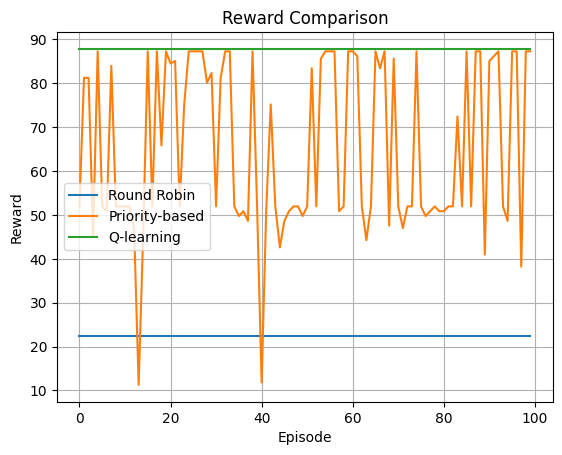

In [100]:
import pandas as pd
# Câu 3: chạy 100 episode với 3 policy, lưu reward vào csv và vẽ biểu đồ so sánh

def run_episode(env, policy_fn, Q=None):
    obs, _ = env.reset()
    terminated = truncated = False
    total_reward = 0

    while not terminated and not truncated:
        if Q is not None:
            action = robot_policy_trained(obs, Q)
        else:
            action = policy_fn(obs)

        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

    return total_reward


def evaluate_policies(episodes=100):
    rr_rewards = []
    pr_rewards = []
    ql_rewards = []

    # Train Q-learning trước
    env_q = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="encoded")
    Q, _ = train_q_learning(env_q, episodes=500)

    for ep in range(episodes):
        # ROUND ROBIN
        env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="dict")
        rr_policy = round_robin_policy(env)
        rr_rewards.append(run_episode(env, rr_policy))

        # PRIORITY
        env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="dict")
        pr_policy = priority_policy(env)
        pr_rewards.append(run_episode(env, pr_policy))

        # Q-LEARNING
        env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="encoded")
        ql_rewards.append(run_episode(env, None, Q))

    return rr_rewards, pr_rewards, ql_rewards



def save_to_csv(rr, pr, ql, filename="results.csv"):
    df = pd.DataFrame({
        "Episode": list(range(1, len(rr)+1)),
        "RoundRobin": rr,
        "Priority": pr,
        "Qlearning": ql
    })
    df.to_csv(filename, index=False)

import os
os.makedirs("metrics", exist_ok=True)  # tạo thư mục nếu chưa có


def plot_comparison(rr, pr, ql):
    plt.plot(rr, label="Round Robin")
    plt.plot(pr, label="Priority-based")
    plt.plot(ql, label="Q-learning")

    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Reward Comparison")
    plt.legend()
    plt.grid()

    plt.show()

if __name__ == "__main__":
    episodes = 100

    rr, pr, ql = evaluate_policies(episodes)

    save_to_csv(rr, pr, ql, "metrics/part_02_comparison_rewards.csv")

    plot_comparison(rr, pr, ql)

     
     
 R#  
     
     
Total reward: 87.85000000000002
Final reward: 87.85000000000002

===== FINAL RESULT =====
Round Robin Reward: 22.449999999999996
Priority-based Reward: 87.30000000000003
Q-learning Reward: 87.85000000000002


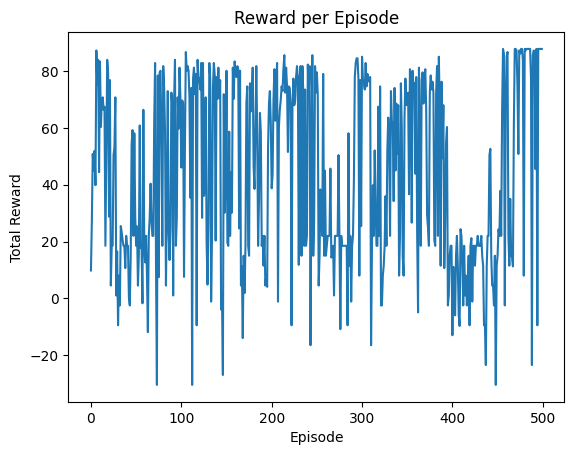

In [101]:
if __name__ == "__main__":

    # ===== ROUND ROBIN =====
    env_rr = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="dict")
    policy_rr = robot_policy("round_robin", env_rr)

    obs, _ = env_rr.reset()
    terminated = truncated = False

    while not terminated and not truncated:
        action = policy_rr(obs)
        obs, reward, terminated, truncated, _ = env_rr.step(action)
        env_rr.render()

    rr_reward = env_rr.total_reward

    # ===== PRIORITY =====
    env_pr = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="dict")
    policy_pr = robot_policy("priority_based", env_pr)

    obs, _ = env_pr.reset()
    terminated = truncated = False

    while not terminated and not truncated:
        action = policy_pr(obs)
        obs, reward, terminated, truncated, _ = env_pr.step(action)
        env_pr.render()

    pr_reward = env_pr.total_reward

    # ===== Q-LEARNING =====
    env_ql = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="encoded")

    Q, rewards = train_q_learning(env_ql, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1)
    
    ql_reward = test_agent(env_ql, Q)

    print("\n===== FINAL RESULT =====")
    print("Round Robin Reward:", rr_reward)
    print("Priority-based Reward:", pr_reward)
    print("Q-learning Reward:", ql_reward)

    plot_rewards(rewards)

Evaluation and Analysis

## Part 3: Q-learning with Load Balancing Problem

In [102]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [103]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            if self.current_task is not None:
                  self.remaining_time -= 1
                  if self.remaining_time == 0:
                        completed_task = self.current_task
                        self.current_task = None
                        self.remaining_time = 0

            # If server becomes idle, immediately pull next task from queue
            else:
                  if len(self.queue) > 0:
                        self.current_task = self.queue.popleft()
                        self.remaining_time = self.current_task.processing_time
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            if self.current_task is None: 
                  self.current_task = task
                  self.remaining_time = self.current_task.processing_time
                  return True

            # Otherwise enqueue if capacity allows
            else:
                  # Queue not full -> enqueue task
                  if len(self.queue) < self.queue_capacity:
                        self.queue.append(task)
                        return True

                  # Queue full -> task dropped
                  return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [104]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.action_space = gym.spaces.Discrete(self.n_servers)

            # Define observation space as a dict containing server states
            self.observation_space = gym.spaces.Tuple([
                  gym.spaces.Tuple((
                  gym.spaces.Box(low=0, high=float('inf'), shape=(), dtype=float),
                  gym.spaces.Discrete(self.queue_capacity + 1)
                  )) for _ in range(self.n_servers)
            ])


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = Task(self.next_task_id, self.rng.randint(1, 5))
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0.0

            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.next_task_id = 0
            self.tasks_created = {}
            self.tasks_completed = set()
            self.tasks_dropped = set()
            self.tasks_accepted = set()


            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, 
            # add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  completed_task = server.run_one_step()
                  if completed_task is not None:
                        self.tasks_completed.add(completed_task.task_id)
                        reward += 2.0


            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if(self.servers[action].add_task(new_task)):
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5.0
      
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) 
            # for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  reward -= 0.5 * len(server.queue)

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            server_states = []
            for server in self.servers:
                state_of_one_server = (float(server.remaining_time), int(server.queue_length()))
                server_states.append(state_of_one_server)
                
            return tuple(server_states)

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if total_created > 0:
                  drop_rate = dropped / total_created
                  completion_rate = completed / total_created
            else:
                  drop_rate = 0.0
                  completion_rate = 0.0
            #...

            return {
                  "time": self.time,
                  "total_created tasks": total_created,
                  "dropped tasks": dropped,
                  "completed tasks": completed,
                  "accepted tasks": accepted,
                  "drop rate": drop_rate,
                  "completion rate": completion_rate
            }

In [105]:
class QLearningAgent:
    # Agent stores Q-values in a dictionary keyed by (state, action).
    # If a (state, action) pair has never been seen, its Q-value is treated as 0.
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha  # Learning rate: how much to update old Q-values
        self.gamma = gamma  # Discount factor: importance of future rewards
        self.q_table = {}   # Sparse Q-table: {(state, action): q_value}

    def get_q_value(self, state, action):
        # Return Q(s, a). If missing, return 0.0 (default for unseen pairs).
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        # Q-learning update rule:
        #   Q(s,a) <- (1 - alpha)*Q(s,a) + alpha*(reward + gamma*max_a' Q(s',a'))
        #
        # 1) Estimate best possible future value at next_state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_next_q = max(
            self.get_q_value(next_state, a) for a in range(self.env.action_space.n)
        )

        # 2) Current estimate for (state, action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        current_q = self.get_q_value(state, action)

        # 3) Temporal-difference target
        # Reward for current step + discounted best future value
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        target_q = reward + self.gamma*best_next_q

        # 4) Blend old estimate with new target
        # New Q-value is a weighted average of old and new information
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        new_q = (1-self.alpha)*current_q + self.alpha*target_q

        # 5) Save updated Q-value
        self.q_table[(state, action)] = new_q

    def choose_action(self, state, epsilon=0.1, option="q_learning"):
        if option == "random":
            return self.env.action_space.sample()
        # Epsilon-greedy action selection:
        # - With probability epsilon: explore (random action)
        # - Otherwise: exploit (choose action with highest Q-value)

        # 1) Exploration: random action with probability epsilon
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if random.random() < epsilon:
            return self.env.action_space.sample()

        # Compute Q-values for all actions in current state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)

        # Tie-breaking: if multiple actions share max Q, choose randomly among them
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_actions = [
            a for a in range(self.env.action_space.n)
            if q_values[a] == max_q
        ]
        return random.choice(best_actions)

    def choose_greedy_action(self, state):
        # Pure greedy policy (epsilon=0):
        # Always choose one of the best actions by Q-value.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)

In [106]:
def load_balancing_policy(option="random", env=None):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE      

      elif option == "round_robin":
            # Khởi tạo rr_index nếu chưa có
            if not hasattr(env, 'rr_index'):
                  env.rr_index = 0
                  
            server = env.rr_index
            env.rr_index = (env.rr_index + 1) % env.n_servers 
            return server
         
      raise ValueError(f"Unsupported policy option: {option}")

In [107]:
def save_metrics(history_ql, history_rr, metrics_dir="metrics"):
      """Convert evaluation histories to DataFrames and save strict CSV files in a metrics folder."""
      from pathlib import Path

      df_ql = pd.DataFrame(history_ql)
      df_rr = pd.DataFrame(history_rr)
      cwd = Path.cwd()
      if cwd.name == "notebooks":
            repo_root = cwd.parent
      elif (cwd / "notebooks").exists():
            repo_root = cwd
      else:
            repo_root = cwd
      metrics_path = repo_root / metrics_dir
      metrics_path.mkdir(parents=True, exist_ok=True)
      ql_file_path = metrics_path / "q_learning_metrics.csv"
      rr_file_path = metrics_path / "round_robin_metrics.csv"
      summary_file_path = metrics_path / "summary_metrics.csv"
      export_columns = [
            "Total_Runtime",
            "Total_Created_Tasks",
            "Accepted_Tasks",
            "Dropped_Tasks",
            "Completed_Tasks",
            "Reward"
      ]
      df_ql[export_columns].to_csv(ql_file_path, index=False)
      df_rr[export_columns].to_csv(rr_file_path, index=False)
      summary_ql = summarize_metrics(df_ql)
      summary_rr = summarize_metrics(df_rr)
      summary_df = pd.DataFrame([
            {"Metric": "Average Reward", "Q-learning": summary_ql["Average Reward"], "Round Robin": summary_rr["Average Reward"]},
            {"Metric": "Drop Rate", "Q-learning": summary_ql["Drop Rate"], "Round Robin": summary_rr["Drop Rate"]},
            {"Metric": "Completion Rate", "Q-learning": summary_ql["Completion Rate"], "Round Robin": summary_rr["Completion Rate"]}
      ])
      summary_df.to_csv(summary_file_path, index=False)
      print(f"Đã xuất dữ liệu Q-learning ra file '{ql_file_path.name}'!")
      print(f"Đã xuất dữ liệu Round Robin ra file '{rr_file_path.name}'!")
      print(f"Đã xuất bảng tổng hợp ra file '{summary_file_path.name}'!")
      return df_ql, df_rr, summary_df

def summarize_metrics(df):
      """Aggregate episode-level metrics for the comparison table."""
      total_created = df["Total_Created_Tasks"].sum()
      dropped = df["Dropped_Tasks"].sum()
      completed = df["Completed_Tasks"].sum()
      average_reward = df["Reward"].mean()
      drop_rate = (dropped / total_created) if total_created > 0 else 0.0
      completion_rate = (completed / total_created) if total_created > 0 else 0.0
      return {
            "Average Reward": average_reward,
            "Drop Rate": drop_rate,
            "Completion Rate": completion_rate
      }

In [108]:
def train_q_learning_agent(env, alpha=0.1, gamma=0.9, num_episodes=5000, steps_per_episode=100, epsilon=0.1):
      """Train a Q-learning agent on the load balancing environment."""
      agent = QLearningAgent(env, alpha=alpha, gamma=gamma)

      for episode in range(num_episodes):
            obs, _ = env.reset()
            state = obs

            for step in range(steps_per_episode):
                  # Chọn hành động (có khám phá epsilon=0.1)
                  action = agent.choose_action(state, epsilon=epsilon)
                  
                  # Tương tác
                  next_obs, reward, terminated, truncated, _ = env.step(action)
                  next_state = next_obs

                  # Học và cập nhật Q-Table
                  agent.update_q_value(state, action, reward, next_state)
                  state = next_state

      return agent

1. Đang huấn luyện Q-Learning Agent (5000 episodes)...
Huấn luyện xong! Agent đã học được 15094 trạng thái.

2. Đang tiến hành đánh giá 2 chiến lược trên 100 episode...
Đã xuất dữ liệu Q-learning ra file 'q_learning_metrics.csv'!
Đã xuất dữ liệu Round Robin ra file 'round_robin_metrics.csv'!
Đã xuất bảng tổng hợp ra file 'summary_metrics.csv'!

BẢNG SO SÁNH HIỆU NĂNG TRÊN 100 EPISODE:
Metric               | Q-learning      | Round Robin    
-------------------------------------------------------
Average Reward       | -24.30          | -84.88         
Drop Rate            | 6.75%           | 14.14%         
Completion Rate      | 85.73%          | 78.38%         

3. Biểu đồ thể hiện sự biến thiên của từng policy theo thời gian với 3 metrics: reward, drop, completion


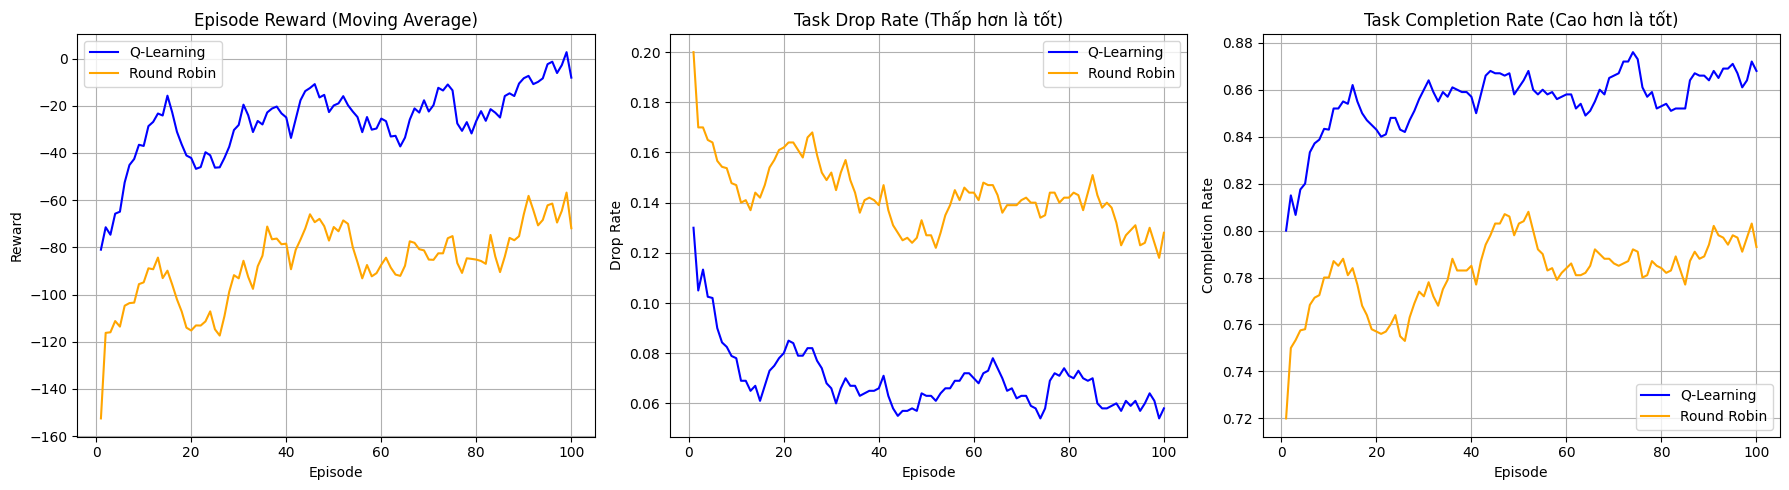

In [109]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      num_train_episodes = 5000
      steps_per_episode = 100

      print(f"1. Đang huấn luyện Q-Learning Agent ({num_train_episodes} episodes)...")
      agent = train_q_learning_agent(
            env,
            alpha=0.1,
            gamma=0.9,
            num_episodes=num_train_episodes,
            steps_per_episode=steps_per_episode,
            epsilon=0.1
      )

      print(f"Huấn luyện xong! Agent đã học được {len(agent.q_table)} trạng thái.")

      # ============================================================
      # BÀI 6 & 7: ĐÁNH GIÁ VÀ SO SÁNH (Q-LEARNING vs ROUND ROBIN)
      # ============================================================
      print("\n2. Đang tiến hành đánh giá 2 chiến lược trên 100 episode...")
      eval_episodes = 100
      eval_steps_per_episode = 100
      eval_seed_base = 2026
      
      # Hàm chạy 1 chiến lược và thu thập lịch sử
      def evaluate_policy(policy_name, \
                          num_episodes=eval_episodes, 
                          steps_per_episode=eval_steps_per_episode, 
                          seed_base=eval_seed_base):
            history = []

            for episode in range(num_episodes):
                  episode_seed = seed_base + episode
                  obs, _ = env.reset(seed=episode_seed)
                  if hasattr(env, 'rr_index'):
                        env.rr_index = 0 # Reset lại bộ đếm Round Robin cho công bằng

                  episode_reward = 0.0
                  state = obs
                  info = {}

                  for step in range(steps_per_episode):
                        if policy_name == "Q-learning":
                              # Dùng trí khôn 100% (Greedy Action), không random nữa
                              action = agent.choose_greedy_action(state)
                        else:
                              action = load_balancing_policy(option="round_robin", env=env)

                        next_obs, reward, terminated, truncated, info = env.step(action)
                        episode_reward += reward
                        state = next_obs

                  # Trích xuất dữ liệu tổng của episode cho bài báo cáo
                  total_runtime = info.get("time", steps_per_episode)
                  total_created = info.get("total_created tasks", 0)
                  accepted = info.get("accepted tasks", 0)
                  dropped = info.get("dropped tasks", 0)
                  completed = info.get("completed tasks", 0)
                  drop_rate = info.get("drop rate", 0.0)
                  completion_rate = info.get("completion rate", 0.0)

                  history.append({
                        "Episode": episode + 1,
                        "Policy": policy_name,
                        "Total_Runtime": total_runtime,
                        "Total_Created_Tasks": total_created,
                        "Accepted_Tasks": accepted,
                        "Dropped_Tasks": dropped,
                        "Completed_Tasks": completed,
                        "Reward": episode_reward,
                        "Drop_Rate": drop_rate,
                        "Completion_Rate": completion_rate
                  })

            return history

      # Chạy thu thập dữ liệu
      history_ql = evaluate_policy("Q-learning")
      history_rr = evaluate_policy("Round Robin")

      # Xuất ra file CSV theo yêu cầu
      df_ql, df_rr, summary_df = save_metrics(history_ql, history_rr)

      summary_ql = summarize_metrics(df_ql)
      summary_rr = summarize_metrics(df_rr)

      # In Bảng So Sánh theo format của đề bài
      print("\nBẢNG SO SÁNH HIỆU NĂNG TRÊN 100 EPISODE:")
      print(f"{'Metric':<20} | {'Q-learning':<15} | {'Round Robin':<15}")
      print("-" * 55)
      
      avg_reward_ql = summary_ql['Average Reward']
      avg_reward_rr = summary_rr['Average Reward']
      print(f"{'Average Reward':<20} | {avg_reward_ql:<15.2f} | {avg_reward_rr:<15.2f}")
      
      drop_rate_ql = summary_ql['Drop Rate']
      drop_rate_rr = summary_rr['Drop Rate']
      print(f"{'Drop Rate':<20} | {drop_rate_ql:<15.2%} | {drop_rate_rr:<15.2%}")
      
      comp_rate_ql = summary_ql['Completion Rate']
      comp_rate_rr = summary_rr['Completion Rate']
      print(f"{'Completion Rate':<20} | {comp_rate_ql:<15.2%} | {comp_rate_rr:<15.2%}")

      # Làm mượt biểu đồ để dễ quan sát xu hướng theo episode
      smoothing_window = 10
      plot_df_ql = df_ql.copy()
      plot_df_rr = df_rr.copy()
      for metric in ['Reward', 'Drop_Rate', 'Completion_Rate']:
            plot_df_ql[metric] = plot_df_ql[metric].rolling(window=smoothing_window, min_periods=1).mean()
            plot_df_rr[metric] = plot_df_rr[metric].rolling(window=smoothing_window, min_periods=1).mean()

      print("\n3. Biểu đồ thể hiện sự biến thiên của từng policy theo thời gian với 3 metrics: reward, drop, completion")

      # Vẽ 3 biểu đồ
      fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

      # Biểu đồ Reward
      ax1.plot(plot_df_ql['Episode'], plot_df_ql['Reward'], label='Q-Learning', color='blue')
      ax1.plot(plot_df_rr['Episode'], plot_df_rr['Reward'], label='Round Robin', color='orange')
      ax1.set_title('Episode Reward (Moving Average)')
      ax1.set_xlabel('Episode'); ax1.set_ylabel('Reward'); ax1.legend(); ax1.grid(True)

      # Biểu đồ Drop Rate
      ax2.plot(plot_df_ql['Episode'], plot_df_ql['Drop_Rate'], label='Q-Learning', color='blue')
      ax2.plot(plot_df_rr['Episode'], plot_df_rr['Drop_Rate'], label='Round Robin', color='orange')
      ax2.set_title('Task Drop Rate (Thấp hơn là tốt)')
      ax2.set_xlabel('Episode'); ax2.set_ylabel('Drop Rate'); ax2.legend(); ax2.grid(True)

      # Biểu đồ Completion Rate
      ax3.plot(plot_df_ql['Episode'], plot_df_ql['Completion_Rate'], label='Q-Learning', color='blue')
      ax3.plot(plot_df_rr['Episode'], plot_df_rr['Completion_Rate'], label='Round Robin', color='orange')
      ax3.set_title('Task Completion Rate (Cao hơn là tốt)')
      ax3.set_xlabel('Episode'); ax3.set_ylabel('Completion Rate'); ax3.legend(); ax3.grid(True)

      plt.tight_layout()
      plt.show()

Evaluation and Analysis

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Lab02 - Introduction to Q-learning.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
